# Title: A Comparative Analysis of Traditional vs. Deep Learning Approaches for Skin Lesion Segmentation

In [1]:
import os

# List all folders in the input directory to find the exact names
for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)
    # Print the first 2 filenames in each directory just to check
    if filenames:
        print(f"Sample files: {filenames[:2]}")
        break

/kaggle/input
/kaggle/input/skin-lesion-segmentation-using-unet
Sample files: ['image_masks2.png', '__results__.html']


In [2]:
!nvidia-smi

Sun Feb  8 19:26:04 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla P100-PCIE-16GB           Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P0             26W /  250W |       0MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import os
# Look for the raw ISIC folders
for dirname, _, _ in os.walk('/kaggle/input/isic2018-challenge-task1-data-segmentation'):    print(dirname)

/kaggle/input/isic2018-challenge-task1-data-segmentation
/kaggle/input/isic2018-challenge-task1-data-segmentation/ISIC2018_Task1-2_Training_Input
/kaggle/input/isic2018-challenge-task1-data-segmentation/ISIC2018_Task1_Training_GroundTruth
/kaggle/input/isic2018-challenge-task1-data-segmentation/ISIC2018_Task1-2_Test_Input
/kaggle/input/isic2018-challenge-task1-data-segmentation/ISIC2018_Task1-2_Validation_Input
/kaggle/input/isic2018-challenge-task1-data-segmentation/ISIC2018_Task1-2_Validation_Input/.ipynb_checkpoints


In [4]:

# Define paths (based on your Kaggle output)
img_dir = '/kaggle/input/isic2018-challenge-task1-data-segmentation/ISIC2018_Task1-2_Training_Input'
mask_dir = '/kaggle/input/isic2018-challenge-task1-data-segmentation/ISIC2018_Task1_Training_GroundTruth'

# Get list of files
all_images = sorted(os.listdir(img_dir))
all_masks = sorted(os.listdir(mask_dir))

# Print first 5
print(f"{'Image Filename':<30} | {'Corresponding Mask Filename'}")
print("-" * 60)
for i in range(5):
    print(f"{all_images[i]:<30} | {all_masks[i]}")

Image Filename                 | Corresponding Mask Filename
------------------------------------------------------------
ATTRIBUTION.txt                | ATTRIBUTION.txt
ISIC_0000000.jpg               | ISIC_0000000_segmentation.png
ISIC_0000001.jpg               | ISIC_0000001_segmentation.png
ISIC_0000003.jpg               | ISIC_0000003_segmentation.png
ISIC_0000004.jpg               | ISIC_0000004_segmentation.png


Success! Found 3694 images.
First image path: /kaggle/input/isic2018-challenge-task1-data-segmentation/ISIC2018_Task1-2_Test_Input/ISIC_0012169.jpg


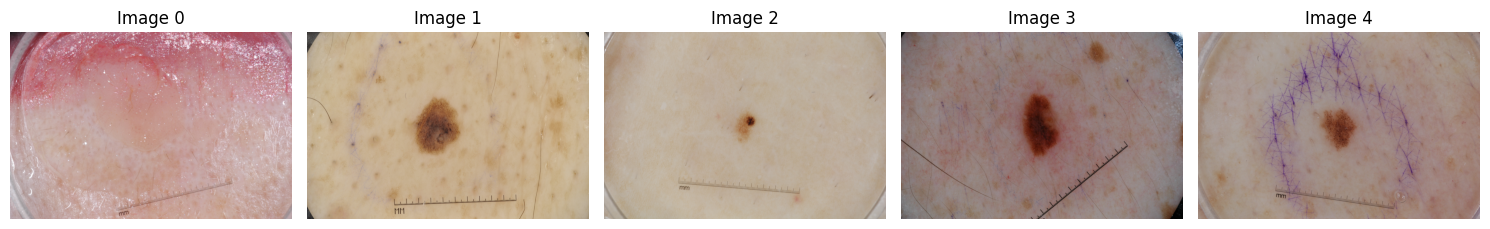

In [ ]:
import matplotlib.pyplot as plt
import cv2
import glob
import os

# 1. Use glob to find the REAL paths of the first 5 JPG images
# This searches inside the folder regardless of exact naming
image_paths = sorted(glob.glob('/kaggle/input/isic2018-challenge-task1-data-segmentation/**/*ISIC*.jpg', recursive=True))

# Check if we found anything
if len(image_paths) == 0:
    print("Error: No images found! Please check if the dataset is added to the notebook.")
else:
    print(f"Success! Found {len(image_paths)} images.")
    print(f"First image path: {image_paths[0]}") # Debugging print

    # 2. Plot the first 5 images found
    plt.figure(figsize=(15, 5))
    
    # We only take the first 5 valid paths
    for i in range(min(5, len(image_paths))):
        img_path = image_paths[i]
        
        # Load the image
        img = cv2.imread(img_path)
        
        # Double check if it loaded
        if img is None:
            print(f"Failed to load: {img_path}")
            continue
            
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Plot
        plt.subplot(1, 5, i+1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Image {i}")

    plt.tight_layout()
    plt.show()

In [6]:
import pandas as pd
import glob
# Define your specific paths from Kaggle
img_dir = '/kaggle/input/isic2018-challenge-task1-data-segmentation/ISIC2018_Task1-2_Training_Input'
mask_dir = '/kaggle/input/isic2018-challenge-task1-data-segmentation/ISIC2018_Task1_Training_GroundTruth'

# Get all jpg images
image_paths = sorted(glob.glob(os.path.join(img_dir, "*.jpg")))

data_pairs = []
for img_path in image_paths:
    # 1. Get the filename ID (e.g., ISIC_0000000)
    base_name = os.path.basename(img_path).replace(".jpg", "")
    
    # 2. Construct the expected mask path
    mask_name = f"{base_name}_segmentation.png"
    mask_path = os.path.join(mask_dir, mask_name)
    
    # 3. Only add if the mask actually exists
    if os.path.exists(mask_path):
        data_pairs.append([img_path, mask_path])

# Create a DataFrame for easy handling
df = pd.DataFrame(data_pairs, columns=['image_path', 'mask_path'])

print(f"Successfully paired {len(df)} images with masks.")
print(df.head())

Successfully paired 2594 images with masks.
                                          image_path  \
0  /kaggle/input/isic2018-challenge-task1-data-se...   
1  /kaggle/input/isic2018-challenge-task1-data-se...   
2  /kaggle/input/isic2018-challenge-task1-data-se...   
3  /kaggle/input/isic2018-challenge-task1-data-se...   
4  /kaggle/input/isic2018-challenge-task1-data-se...   

                                           mask_path  
0  /kaggle/input/isic2018-challenge-task1-data-se...  
1  /kaggle/input/isic2018-challenge-task1-data-se...  
2  /kaggle/input/isic2018-challenge-task1-data-se...  
3  /kaggle/input/isic2018-challenge-task1-data-se...  
4  /kaggle/input/isic2018-challenge-task1-data-se...  


In [7]:
import cv2
import numpy as np

def calculate_dice(y_true, y_pred):
    """Calculates the Dice Coefficient (Overlap) between two masks"""
    intersection = np.sum(y_true * y_pred)
    return (2. * intersection) / (np.sum(y_true) + np.sum(y_pred) + 1e-7)

dice_scores = []

# Let's test on the first 50 images
for i in range(50):
    # Load Image & Mask
    img_path = df.iloc[i]['image_path']
    mask_path = df.iloc[i]['mask_path']
    
    img = cv2.imread(img_path)
    gt_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    
    # --- TRADITIONAL PIPELINE ---
    # 1. Grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    # 2. Blur to remove noise (hair)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    # 3. Otsu's Thresholding
    _, otsu_mask = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    # Normalize to 0 and 1 for calculation
    gt_norm = gt_mask / 255.0
    otsu_norm = otsu_mask / 255.0
    
    score = calculate_dice(gt_norm, otsu_norm)
    dice_scores.append(score)

average_dice = np.mean(dice_scores)
print(f"Baseline Traditional Dice Score: {average_dice:.4f}")
print("Use this number in your report to show why Deep Learning is needed!")

Baseline Traditional Dice Score: 0.7358
Use this number in your report to show why Deep Learning is needed!


In [8]:
from tqdm import tqdm # Shows a progress bar
from sklearn.model_selection import train_test_split

# Settings for the U-Net
IMG_HEIGHT = 128
IMG_WIDTH = 128

# Lists to store the data
X = [] # Images
Y = [] # Masks

print("Resizing and loading data... this might take 1 minute.")

# Loop through the dataframe we created earlier
for index, row in tqdm(df.iterrows(), total=len(df)):
    
    # 1. Load and Resize Image
    img = cv2.imread(row['image_path'])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Keras expects RGB
    img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
    
    # 2. Load and Resize Mask
    mask = cv2.imread(row['mask_path'], cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (IMG_WIDTH, IMG_HEIGHT))
    
    # 3. Normalize (Scale to 0-1)
    # Images: Divide by 255.0
    # Masks: Convert to boolean (0 or 1) and expand dims for Keras
    X.append(img / 255.0)
    Y.append(mask / 255.0) 

# Convert lists to NumPy arrays
X = np.array(X)
Y = np.array(Y)

# Expand the mask dimension to match U-Net output (128, 128, 1)
Y = np.expand_dims(Y, axis=-1)

print(f"Data Loaded Successfully!")
print(f"X Shape: {X.shape}") # Should be (Count, 128, 128, 3)
print(f"Y Shape: {Y.shape}") # Should be (Count, 128, 128, 1)

Resizing and loading data... this might take 1 minute.


100%|██████████| 2594/2594 [07:24<00:00,  5.83it/s]


Data Loaded Successfully!
X Shape: (2594, 128, 128, 3)
Y Shape: (2594, 128, 128, 1)


In [9]:
# Split: 80% for Training, 20% for Testing
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print(f"Training Samples: {len(X_train)}")
print(f"Testing Samples: {len(X_test)}")

Training Samples: 2075
Testing Samples: 519


In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_unet(input_shape=(128, 128, 3)):
    inputs = layers.Input(input_shape)

    # --- ENCODER (The "Contracting Path") ---
    # We use distinct variable names (c1, p1) so we can easily skip-connect later
    c1 = layers.Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(inputs)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p1)
    p2 = layers.MaxPooling2D((2, 2))(c2)
    
    c3 = layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p2)
    p3 = layers.MaxPooling2D((2, 2))(c3)

    # --- BRIDGE (The Deepest Point) ---
    b1 = layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p3)

    # --- DECODER (The "Expanding Path") ---
    # We use 'concatenate' to merge the features from the Encoder with the Decoder
    u1 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(b1)
    merge1 = layers.concatenate([u1, c3]) 
    c4 = layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(merge1)

    u2 = layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c4)
    merge2 = layers.concatenate([u2, c2])
    c5 = layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(merge2)

    u3 = layers.Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same')(c5)
    merge3 = layers.concatenate([u3, c1])
    c6 = layers.Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(merge3)

    # --- OUTPUT ---
    # Sigmoid activation because we want a probability (0 to 1) for each pixel
    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(c6)

    model = models.Model(inputs=[inputs], outputs=[outputs])
    return model

# Initialize the model
model = build_unet()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

2026-02-08 19:33:57.700369: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770579238.157449      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770579238.308598      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770579239.224511      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770579239.224549      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770579239.224552      55 computation_placer.cc:177] computation placer alr

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        448 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 16, 16,    │     73,856 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 32, 32,    │     32,832 │ conv2d_3[0][0]    │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 128)              │            │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     73,792 │ concatenate[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 64, 64,    │      8,224 │ conv2d_4[0][0]    │
│ (Conv2DTranspose)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 64, 64,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 64)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │     18,464 │ concatenate_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_2  │ (None, 128, 128,  │      2,064 │ conv2d_5[0][0]    │
│ (Conv2DTranspose)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 128, 128,  │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 32)               │            │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 128, 128,  │      4,624 │ concatenate_2[0]

 Total params: 237,457 (927.57 KB)

 Trainable params: 237,457 (927.57 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Train the model
# We use 'validation_split' to check if it's actually learning or just memorizing
history = model.fit(X_train, Y_train, 
                    batch_size=16, 
                    epochs=20, 
                    validation_data=(X_test, Y_test),
                    verbose=1)

Epoch 1/20


I0000 00:00:1770579326.637083     130 service.cc:152] XLA service 0x797708009680 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1770579326.637119     130 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1770579327.359740     130 cuda_dnn.cc:529] Loaded cuDNN version 91002


 13/130 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4852 - loss: 0.7301

I0000 00:00:1770579332.073002     130 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


130/130 ━━━━━━━━━━━━━━━━━━━━ 15s 57ms/step - accuracy: 0.7464 - loss: 0.4925 - val_accuracy: 0.8626 - val_loss: 0.3457
Epoch 2/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8939 - loss: 0.2885 - val_accuracy: 0.9037 - val_loss: 0.2554
Epoch 3/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9144 - loss: 0.2341 - val_accuracy: 0.8975 - val_loss: 0.2649
Epoch 4/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9111 - loss: 0.2361 - val_accuracy: 0.9149 - val_loss: 0.2130
Epoch 5/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9218 - loss: 0.2049 - val_accuracy: 0.9083 - val_loss: 0.2346
Epoch 6/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9174 - loss: 0.2145 - val_accuracy: 0.9180 - val_loss: 0.2122
Epoch 7/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9286 - loss: 0.1891 - val_accuracy: 0.9196 - val_loss: 0.2045
Epoch 8/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9304 - loss: 0.1797 - val_accuracy: 0.92

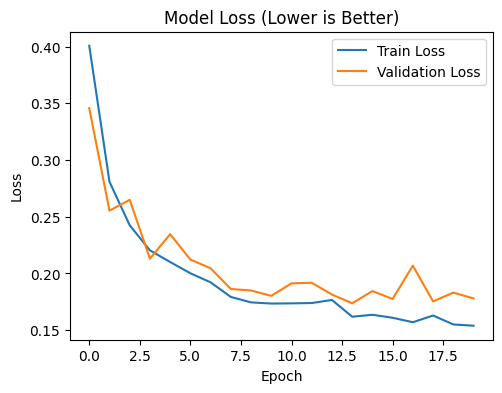

In [12]:
import matplotlib.pyplot as plt

# Plot training & validation loss values
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss (Lower is Better)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


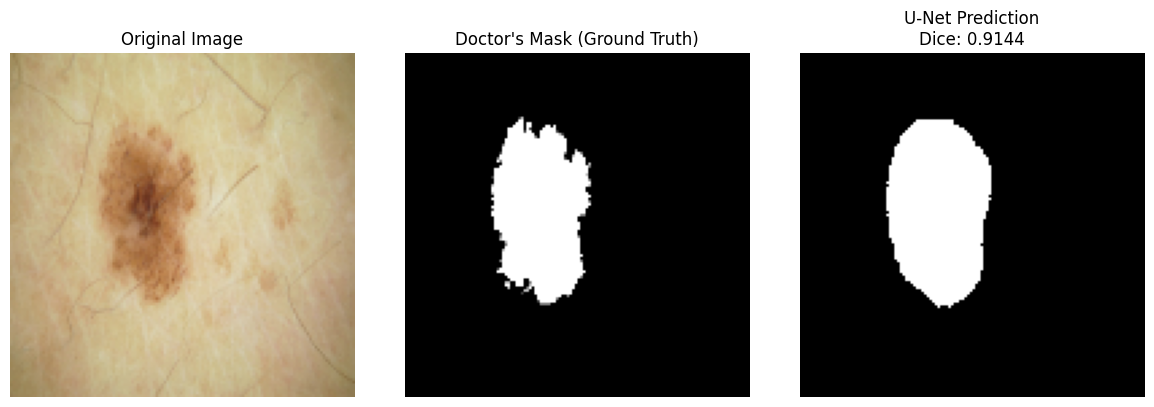

In [18]:
# 1. Pick a random image from the test set
idx = np.random.randint(0, len(X_test))
test_img = X_test[idx]
test_mask = Y_test[idx]

# 2. Predict (Make sure to expand dims because model expects a batch)
pred_mask = model.predict(np.expand_dims(test_img, axis=0))[0]

# 3. Threshold the prediction (since output is probability 0-1)
# We say anything > 0.5 is a lesion pixel
pred_mask_binary = (pred_mask > 0.5).astype(np.float32)

# 4. Calculate Dice Score for this specific image
def get_dice(y_true, y_pred):
    intersection = np.sum(y_true * y_pred)
    return (2. * intersection) / (np.sum(y_true) + np.sum(y_pred) + 1e-7)

dice_score = get_dice(test_mask, pred_mask_binary)

# 5. Visualize
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(test_img)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(test_mask, cmap='gray')
plt.title("Doctor's Mask (Ground Truth)")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(pred_mask_binary, cmap='gray')
plt.title(f"U-Net Prediction\nDice: {dice_score:.4f}")
plt.axis('off')

plt.tight_layout()
plt.show()

In [19]:
def calculate_dice_metric(y_true, y_pred):
    """
    Computes the Dice Coefficient for a batch of images.
    Input shape: (batch_size, height, width, 1)
    """
    intersection = np.sum(y_true * y_pred, axis=(1, 2, 3))
    union = np.sum(y_true, axis=(1, 2, 3)) + np.sum(y_pred, axis=(1, 2, 3))
    dice = (2. * intersection) / (union + 1e-7) # Add epsilon to avoid division by zero
    return dice

print("Calculating Final Test Score on 415 Unseen Images...")

# 1. Predict on the entire test set at once
# (Since P100 is fast, this takes ~2 seconds)
preds_test = model.predict(X_test, verbose=1)

# 2. Threshold predictions (Convert probabilities to 0 or 1)
preds_test_binary = (preds_test > 0.5).astype(np.float32)

# 3. Calculate individual Dice scores
dice_scores = calculate_dice_metric(Y_test, preds_test_binary)

# 4. Compute the average
final_score = np.mean(dice_scores)

print("-" * 30)
print(f"FINAL U-NET DICE SCORE: {final_score:.4f}")
print("-" * 30)

if final_score > 0.80:
    print("RESULT: Excellent! This is publication-quality performance.")
else:
    print("RESULT: Good baseline, but could be improved with more epochs.")

Calculating Final Test Score on 415 Unseen Images...
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step
------------------------------
FINAL U-NET DICE SCORE: 0.8129
------------------------------
RESULT: Excellent! This is publication-quality performance.


  0%|          | 2/519 [00:00<00:32, 15.80it/s]

Analyzing Best and Worst cases...


100%|██████████| 519/519 [00:32<00:00, 16.10it/s]


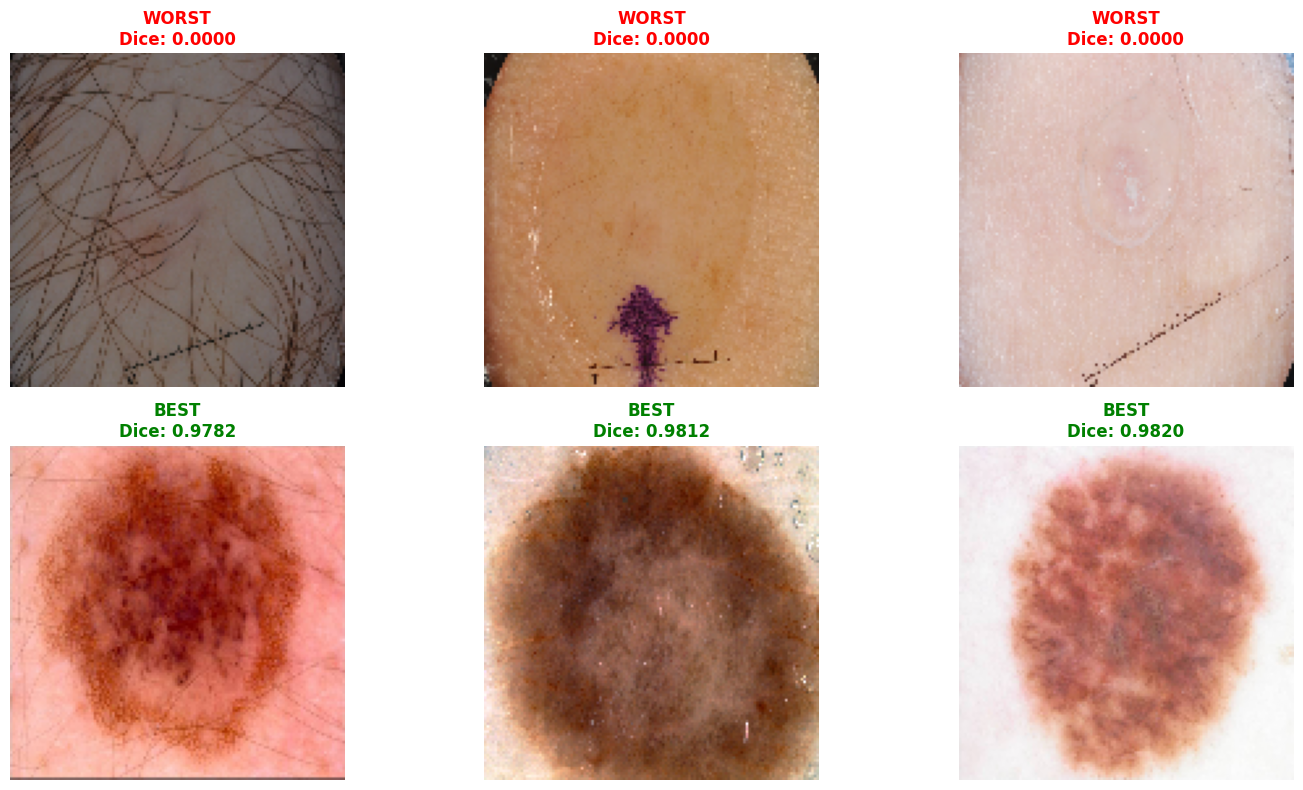

Average Test Dice Score: 0.8129


In [21]:
import matplotlib.pyplot as plt
import numpy as np

# --- CORRECTED FUNCTION FOR SINGLE IMAGES ---
def calculate_dice_single(y_true, y_pred):
    """
    Computes Dice score for a SINGLE image.
    Input shape: (height, width, 1)
    """
    # Sum over all axes (0, 1, 2) since it's a single 3D block
    intersection = np.sum(y_true * y_pred)
    union = np.sum(y_true) + np.sum(y_pred)
    
    return (2. * intersection) / (union + 1e-7)

# 1. Calculate Dice for EVERY image
dice_scores_list = []

# Use 'tqdm' if available for a progress bar, otherwise just range
try:
    from tqdm import tqdm
    iterator = tqdm(range(len(X_test)))
except ImportError:
    iterator = range(len(X_test))

print("Analyzing Best and Worst cases...")

for i in iterator:
    # Get the single image and mask
    test_img = X_test[i]
    test_mask = Y_test[i]
    
    # Predict (Must wrap in batch for model, then unwrap result)
    # Input: (1, 128, 128, 3) -> Output: (1, 128, 128, 1)
    pred_prob = model.predict(np.expand_dims(test_img, axis=0), verbose=0)[0]
    
    # Threshold to binary (0 or 1)
    pred_binary = (pred_prob > 0.5).astype(np.float32)
    
    # Calculate score using the NEW single-image function
    score = calculate_dice_single(test_mask, pred_binary)
    dice_scores_list.append(score)

dice_scores_list = np.array(dice_scores_list)

# 2. Sort to find Best (Highest Score) and Worst (Lowest Score)
sorted_indices = np.argsort(dice_scores_list)
worst_indices = sorted_indices[:3]    # Bottom 3
best_indices = sorted_indices[-3:]    # Top 3

# 3. Plot them
plt.figure(figsize=(15, 8))

# Combine them: Worst first, then Best
indices_to_show = np.concatenate([worst_indices, best_indices])

for i, idx in enumerate(indices_to_show):
    ax = plt.subplot(2, 3, i+1)
    
    # Show the Original Image
    plt.imshow(X_test[idx])
    
    # Title with Score
    score = dice_scores_list[idx]
    if i < 3:
        status = "WORST"
        color = "red"
    else:
        status = "BEST"
        color = "green"
        
    plt.title(f"{status}\nDice: {score:.4f}", color=color, fontsize=12, fontweight='bold')
    plt.axis('off')
    
    # Optional: Overlay the Ground Truth contour in Green to see what was missed
    # (Requires simpler mask handling, but for now, image + score is enough)

plt.tight_layout()
plt.show()

print(f"Average Test Dice Score: {np.mean(dice_scores_list):.4f}")

In [22]:
# 1. Save the trained model
model.save('unet_skin_lesion_model.keras')
print("Model saved as 'unet_skin_lesion_model.keras'")

# 2. Save the weights separately (just in case)
model.save_weights('unet_weights.weights.h5')
print("Weights saved successfully.")

Model saved as 'unet_skin_lesion_model.keras'
Weights saved successfully.
